In [3]:
# Put scripts/ on the path so `eval.*` and `fifedata`/`load` import regardless of
# where the kernel started. Paths in the figure cells are relative to this notebook
# (../output/), so the working directory is left alone. Run this cell first.
import os
import pathlib
import sys

_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "eval").is_dir())
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
os.makedirs(_ROOT / "output", exist_ok=True)
print(f"project root: {_ROOT}  (cwd unchanged: {pathlib.Path.cwd()})")


project root: /opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts  (cwd unchanged: /opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/notebooks)


### Reloading data

In [4]:
%%time
# Loads the data AND reproduces the exact splits the harness trained on, so figures
# here reconcile with results/*.json. The npz `tr_mask`/`te_mask` are NOT that split:
# they are the QDate month split (Feb-Jun / Jul-Aug), which differs from the
# label-observation split by the boundary jobs -- the population the leakage argument
# is about. Use d.train()/d.test() rather than those masks.
import numpy as np

from eval.dataset import load_experiment

EXPERIMENT = "e2"          # e1 | e2 | e2dist | e3 -- picks the matrix and label time
SPLIT = "temporal"         # temporal | random

d = load_experiment(EXPERIMENT)

Xmatch, Xsub = d.Xmatch, d.Xsub
failed, hw, wait_sv = d.failed, d.hw, d.wait_sv
XMATCH_COLS, XSUB_COLS = d.xmatch_cols, d.xsub_cols
NCAT_MATCH, NCAT_SUB = d.ncat_match, d.ncat_sub
cards, n_base = d.schema["cards"], d.schema["n_base"]
X = Xmatch[:, :n_base]

# Index arrays, not boolean masks -- these are what the harness uses.
tr_idx, te_idx = d.train(SPLIT), d.test(SPLIT)

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"{EXPERIMENT}/{SPLIT}: train {len(tr_idx):,} | test {len(te_idx):,}")


[temporal split] train 48,542,883 | test 15,545,475 | 8,936 boundary jobs moved to test | 0 rows fell back to queue time
<ExperimentData e2 @ 2025-07-01  random: train 48,542,883 / test 15,545,475  temporal: train 48,542,883 / test 15,545,475>
Loaded Xmatch (64088358, 44) and Xsub (64088358, 27)
e2/temporal: train 48,542,883 | test 15,545,475
CPU times: user 17.4 s, sys: 1.91 s, total: 19.3 s
Wall time: 17.7 s


In [5]:
import glob
import os

from eval.paths import all_model_dirs

# Saved as models/<experiment>/<model>/<lib>_<kind>_<split>.<ext>, so select on the
# filename parts rather than on a fixed directory. A multi-seed run leaves the last
# seed's model; per-seed numbers live in the results JSON, not here.
SPLIT = "temporal"

model_paths = []
for d in all_model_dirs():
    if not os.path.exists(d):
        continue
    for ext in ["*.pt", "*.zip", "*.joblib", "*.pkl", "*.model", "*.bin", "*.txt", "*.json"]:
        for path in glob.glob(os.path.join(d, ext)):
            if f"_reg_{SPLIT}" in os.path.basename(path) and f"{os.sep}e2{os.sep}" in path:
                print("appending model path:", path)
                model_paths.append(path)

print(f"Found {len(model_paths)} candidate model file(s).")

appending model path: /mnt/scratch/fast0/amaustin/models/e2/catboost/catboost_reg_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/lightgbm/lightgbm_reg_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/models/e2/xgboost/xgboost_reg_temporal.json
Found 3 candidate model file(s).


### Re-evaluating models (skip if needed)

In [ ]:
%%time
import os
import json
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_wait_models

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

X_test = Xsub[te_idx]
y_test_raw = wait_sv[te_idx]
campaign_ids_test = X_test[:, XSUB_COLS.index("CampaignId")]
campaign_group_cols_test = {"Group": X_test[:, XSUB_COLS.index("Group")]}

df_results, results_by_model, campaign_by_model = evaluate_wait_models(
    model_paths=model_paths,
    X_test=X_test,
    y_test_raw=y_test_raw,
    is_log_pred=True,
    campaign_ids=campaign_ids_test,
    campaign_group_cols=campaign_group_cols_test,
)

wait_json_path = "../output/wait_time_results.json"
data = {}
if os.path.exists(wait_json_path) and os.path.getsize(wait_json_path) > 0:
    with open(wait_json_path) as f:
        data = json.load(f)
for raw_key, mm in results_by_model.items():
    data.setdefault(raw_key, {})["temporal"] = mm
with open(wait_json_path, "w") as f:
    json.dump(data, f, indent=2)

campaign_json_path = "../output/wait_time_campaign_results.json"
with open(campaign_json_path, "w") as f:
    json.dump(campaign_by_model, f, indent=2)

print(
    f"Appended {wait_json_path}; saved per-campaign breakdown for "
    f"{len(campaign_by_model)} models to {campaign_json_path}. "
    f"Figures below read df_results/results_by_model/campaign_by_model "
    f"directly from this cell, not from disk."
)

### Performance by model and wait-time bin

Reads the completed runs from `results/wait_time_results.json` rather than the
in-memory `df_results` above, so the figure renders without re-running inference.

In [14]:
import json
import numpy as np
import pandas as pd
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import (MODEL_DISPLAY_NAMES, PREFERRED_MODEL_ORDER,
                         WAIT_REGIMES)

RESULTS_PATH = "../results/wait_time_results.json"
SPLIT = "temporal"
# A model with r2_log < 0 does worse than predicting the mean wait for every
# job, so its per-bin errors describe a model no one would deploy. Flip to
# False to keep them in the figures for diagnostic purposes.
DROP_NEGATIVE_R2 = True

# results/wait_time_results.json is APPEND-ONLY, so it still holds entries from runs
# that predate the current feature matrices and the fit-derived error bins. Rather
# than naming the models that have been rerun -- a list that goes stale the moment
# another finishes -- select on whether an entry carries the new regime keys. An old
# entry has only the legacy <10m / 10m-2h / >2h bins and is skipped automatically.
REGIME_KEYS = [f"mae_{name}" for name, _, _ in WAIT_REGIMES]
REQUIRE_CURRENT_BINS = True

# Seeded entries are keyed "<split>__seed<n>"; the plain key is the headline run.
# Set to a seed number to plot that one instead.
SEED = None
_key = SPLIT if SEED is None else f"{SPLIT}__seed{SEED}"

with open(RESULTS_PATH) as f:
    _raw = json.load(f)

_rows, _stale = [], []
for key, splits in _raw.items():
    if _key not in splits:
        continue
    rec = splits[_key]
    if REQUIRE_CURRENT_BINS and not all(k in rec for k in REGIME_KEYS):
        _stale.append(MODEL_DISPLAY_NAMES.get(key, key))
        continue
    _rows.append({"model": MODEL_DISPLAY_NAMES.get(key, key), **rec})

df_wait = pd.DataFrame(_rows)
if df_wait.empty:
    raise RuntimeError(f"no entries with the current bins for split '{_key}' -- "
                       f"rerun the harness, or set REQUIRE_CURRENT_BINS = False")

_dropped = df_wait.loc[df_wait["r2_log"] < 0, "model"].tolist()
if DROP_NEGATIVE_R2 and _dropped:
    df_wait = df_wait[df_wait["r2_log"] >= 0]

# Ordered by PREFERRED_MODEL_ORDER (trees first, then neural), matching the README
# and run_sweep.sh, so every figure and table can be read position by position.
# Anything not in that list sorts last, alphabetically.
_ORDER = [MODEL_DISPLAY_NAMES.get(k, k) for k in PREFERRED_MODEL_ORDER]
_rank = {name: i for i, name in enumerate(dict.fromkeys(_ORDER))}
df_wait = (df_wait
           .assign(_rank=df_wait["model"].map(lambda m: _rank.get(m, len(_rank))))
           .sort_values(["_rank", "model"])
           .drop(columns="_rank")
           .set_index("model"))

print(f"{RESULTS_PATH} :: {_key} :: {len(df_wait)} model(s)")
if _stale:
    print(f"  skipped (pre-date the current bins, not yet rerun): {', '.join(sorted(_stale))}")
if _dropped:
    kept = "excluded" if DROP_NEGATIVE_R2 else "kept"
    print(f"  r2_log < 0 ({kept}): {', '.join(_dropped)}")
display(df_wait[["r2_log", "median_ae_s", "mae_raw_s", "within2x"]].round(3))


../results/wait_time_results.json :: temporal :: 3 model(s)
  skipped (pre-date the current bins, not yet rerun): FT-Transformer, Hierarchical, MLP, SAINT, TSMixer, TabNet


,r2_log,median_ae_s,mae_raw_s,within2x
model,,,,
CatBoost,0.223,1820.031,10469.958,0.293
XGBoost,0.277,1911.586,10800.357,0.292
LightGBM,0.250,1916.603,11170.558,0.281


Test samples: 13,532,387
Wait range: 1.0s to 1245639.0s | Global Median: 2082.0s (34.7m)


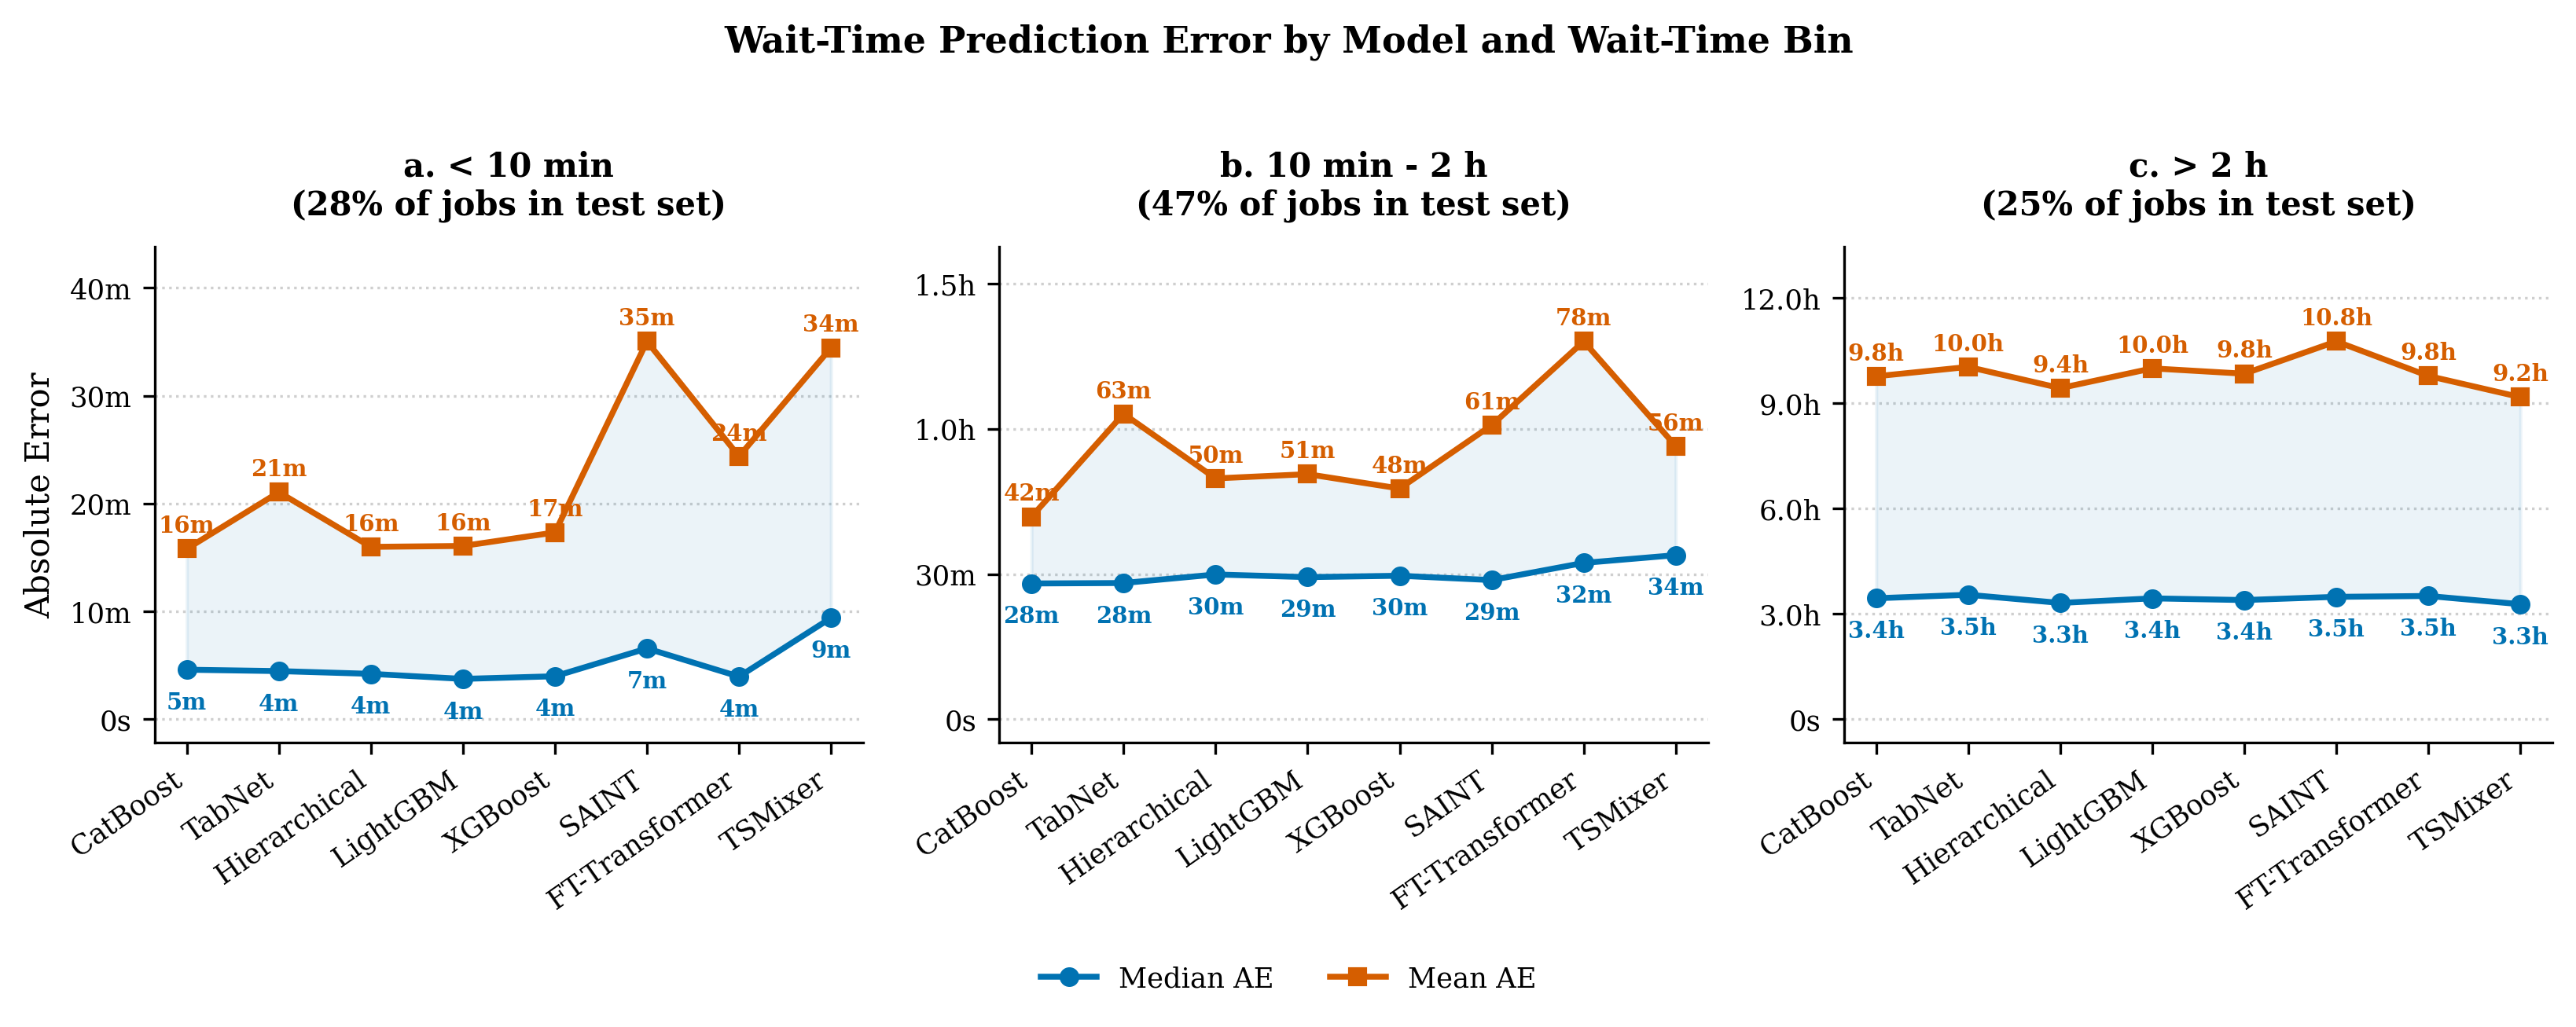

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# 1. Clean and inspect test wait times
y_test_raw = np.asarray(wait_sv[te_idx], dtype=np.float64).ravel()
y_test_raw = y_test_raw[~np.isnan(y_test_raw)]  # Drop NaNs

# Auto-detect log-transformed wait times (e.g., log1p seconds max out ~10-15)
if y_test_raw.max() < 25.0:
  y_test_raw = np.expm1(y_test_raw)

# Auto-detect millisecond wait times (e.g., values in 1e6+)
if np.median(y_test_raw) > 100000:
  y_test_raw = y_test_raw / 1000.0

global_median_wait = float(np.median(y_test_raw))

print(f"Test samples: {len(y_test_raw):,}")
print(
    f"Wait range: {y_test_raw.min():.1f}s to {y_test_raw.max():.1f}s | Global"
    f" Median: {global_median_wait:.1f}s ({global_median_wait/60:.1f}m)"
)

# 2. Figure styling
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "primary": "#0072B2",  # Median AE
    "secondary": "#D55E00",  # Mean AE
    "baseline": "#222222",  # Baseline contrast line
}

# Error bins are the queueing REGIMES recovered by the lognormal-mixture fit on the
# FermiGrid wait distribution (data-analysis.ipynb, cell `fgmix`), not round numbers.
# The fitted components have medians 28 s / 779 s / 2.50 h, and one component
# overtakes the next at 106 s and 2,857 s; those crossovers round to 2 min and 45 min.
# Each bin is therefore a distinct queueing mechanism rather than an arbitrary cut:
#   inst -- matched into an already-idle pilot slot
#   turn -- waiting for an occupied slot to turn over
#   prov -- waiting for new pilot provisioning
#   park -- beyond the 1 d cap: NOT a fitted component, just the tail past the
#           fit population, kept separate so its ~20x larger errors do not swamp prov
BINS = [
    ("a. < 2 min", "median_ae_inst", "mae_inst", (0, 120), "s"),
    ("b. 2 min - 45 min", "median_ae_turn", "mae_turn", (120, 2700), None),
    ("c. 45 min - 1 day", "median_ae_prov", "mae_prov", (2700, 86400), None),
    ("d. > 1 day", "median_ae_park", "mae_park", (86400, None), None),
]


def _dur(s, min_unit=5400, unit=None):
  if s <= 0:
    return "0s"
  if unit == "s":          # forced, e.g. the sub-2-minute panel
    return f"{s:.0f}s"
  if s < 60:
    return f"{s:.0f}s"
  if s < min_unit:
    return f"{s / 60:.0f}m"
  if s < 86400:
    return f"{s / 3600:.1f}h"
  return f"{s / 86400:.1f}d"


def _nice_step(vmax):
  for step in (
      30,
      60,
      120,
      300,
      600,
      900,
      1800,
      3600,
      7200,
      10800,
      21600,
      43200,
  ):
    if vmax / step <= 5:
      return step
  return 86400


models = df_wait.index.tolist()
x = np.arange(len(models))

# The >1 d row is computed and stored by reg_metrics, but not plotted: it is the
# outlier tail beyond the mixture fit's population rather than a queueing regime,
# and its ~2-day errors would compress the three real regimes into the baseline.
PLOT_BINS = [b for b in BINS if b[2] != "mae_park"]

# Draw the "predict the global median for everything" reference line?
# It sits far above the model errors in the short bins, so it dominates
# the y-scale when shown.
SHOW_BASELINE = False

fig, axes = plt.subplots(1, len(PLOT_BINS), figsize=(3.7 * len(PLOT_BINS), 3.8),
                         dpi=300)

for ax, (label, med_k, mean_k, (lo, hi), unit) in zip(axes, PLOT_BINS):
  med = df_wait[med_k].values
  mean = df_wait[mean_k].values

  # Filter test jobs falling into this specific bin
  msk = (
      (y_test_raw >= lo) & (y_test_raw < hi)
      if hi is not None
      else (y_test_raw >= lo)
  )

  # Baseline error: median absolute error when predicting global median
  if msk.any():
    base_ae = float(np.median(np.abs(y_test_raw[msk] - global_median_wait)))
    bin_pct = msk.mean()
  else:
    base_ae = 0.0
    bin_pct = 0.0

  # Model lines
  ax.plot(
      x,
      med,
      marker="o",
      linewidth=1.8,
      markersize=5,
      color=COLORS["primary"],
      label="Median AE",
      zorder=4,
  )
  ax.plot(
      x,
      mean,
      marker="s",
      linewidth=1.8,
      markersize=5,
      color=COLORS["secondary"],
      label="Mean AE",
      zorder=4,
  )
  ax.fill_between(
      x, med, mean, color=COLORS["primary"], alpha=0.08, zorder=2
  )

  # Baseline horizontal line -- off by default; SHOW_BASELINE also controls
  # whether the y-axis reserves room for it.
  # if SHOW_BASELINE and base_ae > 0:
  #   ax.axhline(
  #       base_ae,
  #       ls="--",
  #       lw=1.5,
  #       color=COLORS["baseline"],
  #       zorder=5,
  #       label="Baseline Error: |actual wait - global median|",
  #   )

  # Point labels
  for i, (m_val, mean_val) in enumerate(zip(med, mean)):
    if not (np.isfinite(m_val) and np.isfinite(mean_val)):
      continue
    ax.annotate(
        _dur(m_val, unit=unit),
        (x[i], m_val),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        fontsize=7,
        color=COLORS["primary"],
        fontweight="bold",
    )
    ax.annotate(
        _dur(mean_val, unit=unit),
        (x[i], mean_val),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=7,
        color=COLORS["secondary"],
        fontweight="bold",
    )

  # Axis scaling. `base_ae` is included only when the baseline line is actually
  # drawn: it is the error from predicting the global median (~2,088 s) for every
  # job, which in the sub-2-minute bin is ~2,030 s and would scale that panel to
  # 2,400 s for values that never exceed 475 s.
  #
  # NaN-safe: a model whose entry predates these bins has no value for this key, so
  # pandas fills NaN and a plain max() propagates it into set_ylim, which raises
  # "Axis limits cannot be NaN or Inf". Those models are normally filtered out
  # upstream, but the figure should not depend on that having happened.
  _extra = [base_ae] if SHOW_BASELINE else []
  _finite = np.concatenate([med[np.isfinite(med)], mean[np.isfinite(mean)],
                            np.array(_extra, dtype=float)])
  top = (float(_finite.max()) if _finite.size else 1.0) * 1.25
  if not np.isfinite(top) or top <= 0:
      top = 1.0
  ax.set_ylim(-0.05 * top, top)

  step = _nice_step(top)
  ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
  ax.yaxis.set_major_formatter(
      mticker.FuncFormatter(lambda v, _, u=unit: _dur(v, 3600, unit=u))
  )

  ax.set_title(f"{label}\n({bin_pct:.0%} of jobs in test set)", pad=10, fontweight="bold")
  ax.set_xticks(x)
  ax.set_xticklabels(models, rotation=35, ha="right")
  ax.grid(axis="x", visible=False)
  ax.set_axisbelow(True)

axes[0].set_ylabel("Absolute Error")

# Collect legend handles uniquely across all subplots
handles_dict = {}
for ax in axes:
  h_list, l_list = ax.get_legend_handles_labels()
  for h, l in zip(h_list, l_list):
    if l not in handles_dict:
      handles_dict[l] = h

fig.legend(
    handles_dict.values(),
    handles_dict.keys(),
    loc="lower center",
    ncol=len(handles_dict),
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    f"Wait-Time Prediction Error by Model and Wait-Time Bin",
    y=1.03,
    fontsize=11,
    fontweight="bold",
)

os.makedirs("output", exist_ok=True)
plt.tight_layout()
plt.savefig("../output/wait_error_by_bin.pdf", bbox_inches="tight")
plt.show()

Test samples: 13,592,837
Wait range: 1.0s to 1245639.0s | Global Median: 2088.0s (34.8m)


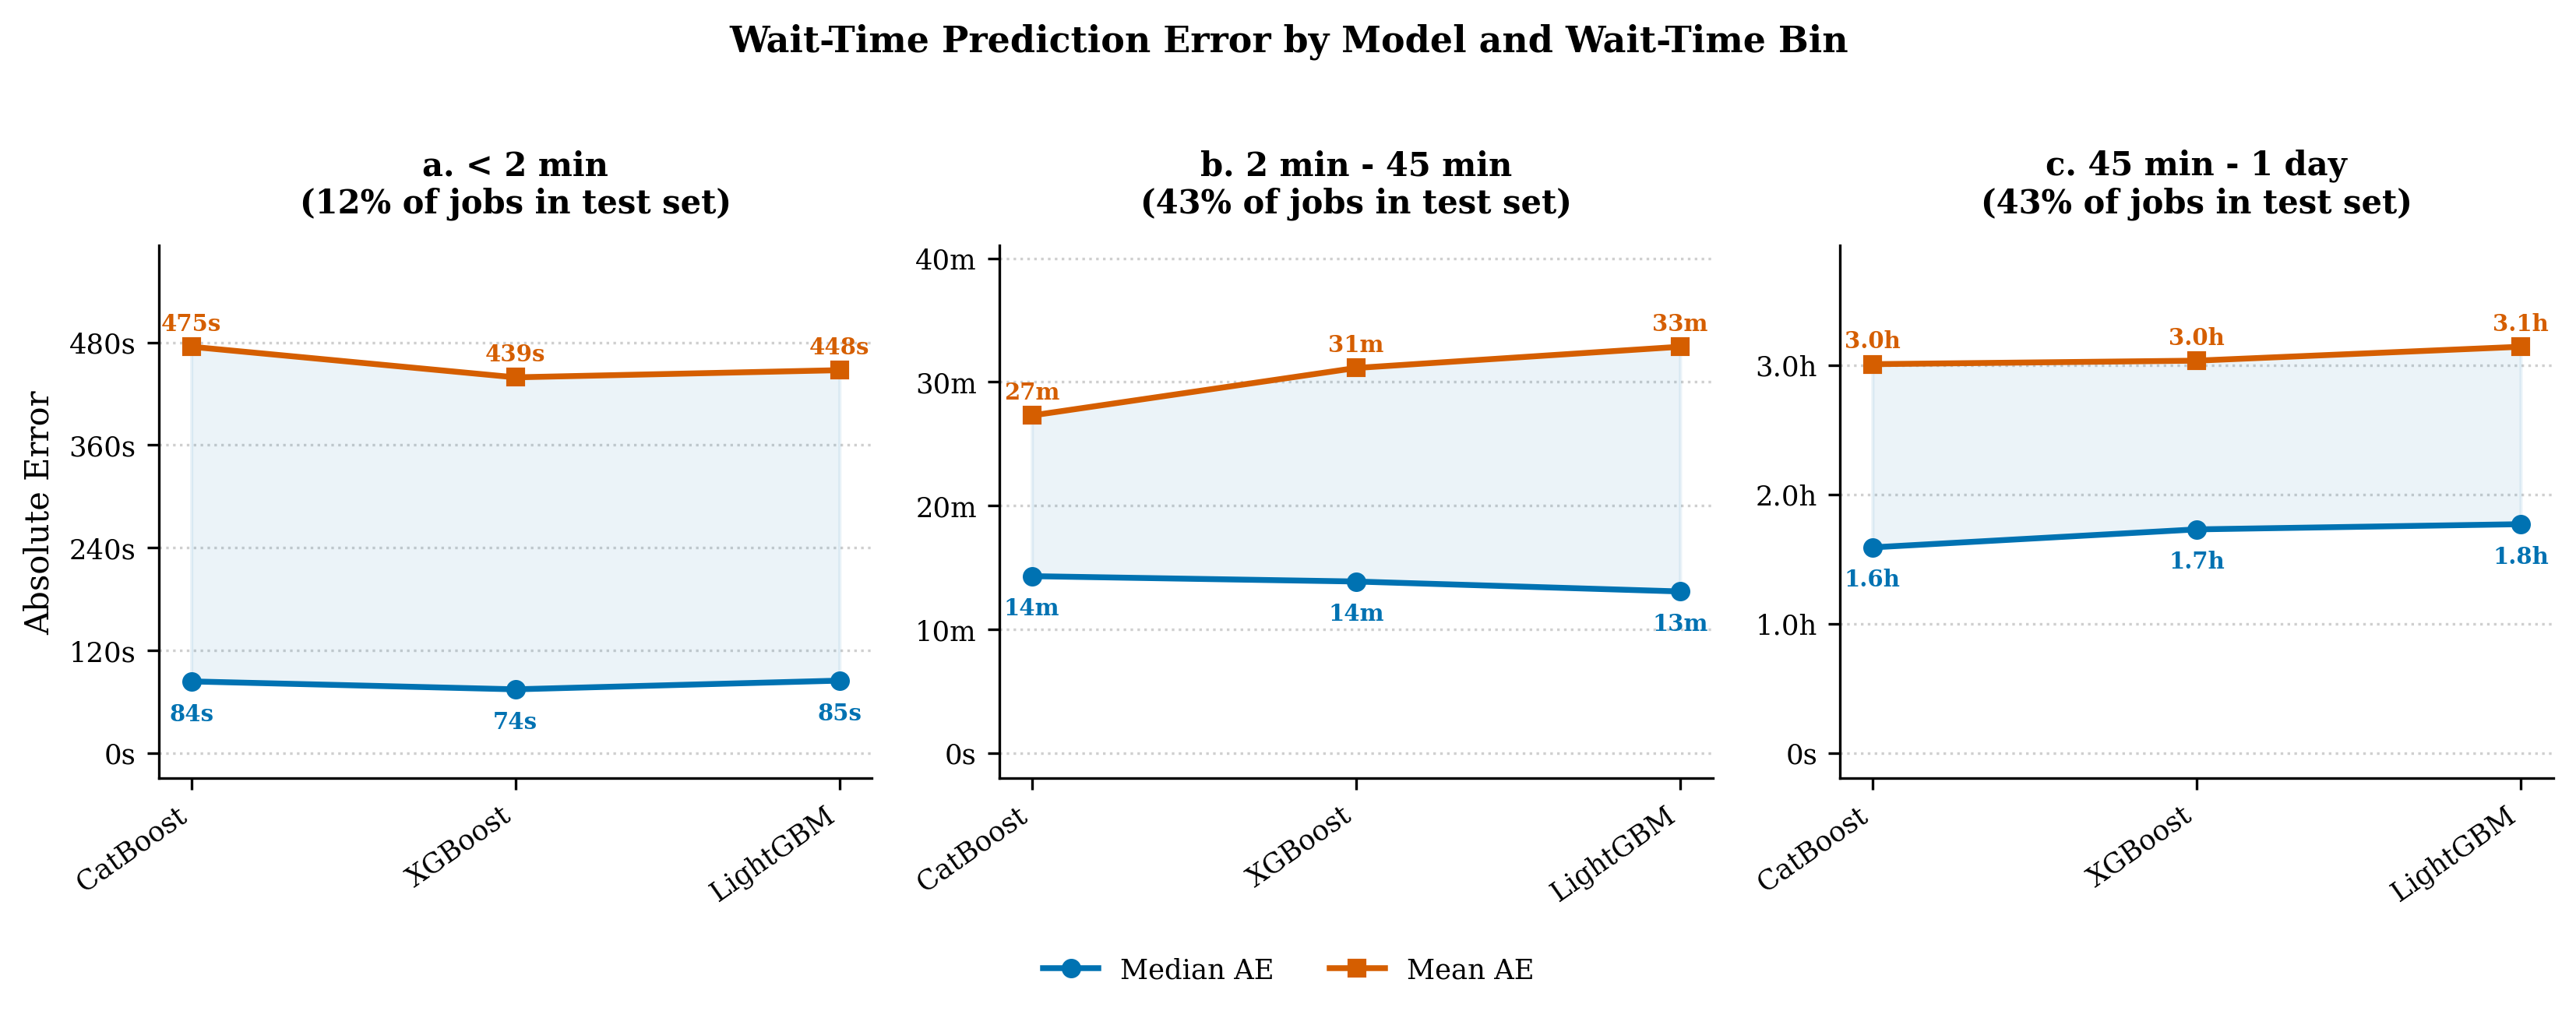

In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# 1. Clean and inspect test wait times
y_test_raw = np.asarray(wait_sv[te_idx], dtype=np.float64).ravel()
y_test_raw = y_test_raw[~np.isnan(y_test_raw)]  # Drop NaNs

# Auto-detect log-transformed wait times (e.g., log1p seconds max out ~10-15)
if y_test_raw.max() < 25.0:
  y_test_raw = np.expm1(y_test_raw)

# Auto-detect millisecond wait times (e.g., values in 1e6+)
if np.median(y_test_raw) > 100000:
  y_test_raw = y_test_raw / 1000.0

global_median_wait = float(np.median(y_test_raw))

print(f"Test samples: {len(y_test_raw):,}")
print(
    f"Wait range: {y_test_raw.min():.1f}s to {y_test_raw.max():.1f}s | Global"
    f" Median: {global_median_wait:.1f}s ({global_median_wait/60:.1f}m)"
)

# 2. Figure styling
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "primary": "#0072B2",  # Median AE
    "secondary": "#D55E00",  # Mean AE
    "baseline": "#222222",  # Baseline contrast line
}

# Error bins are the queueing REGIMES recovered by the lognormal-mixture fit on the
# FermiGrid wait distribution (data-analysis.ipynb, cell `fgmix`), not round numbers.
# The fitted components have medians 28 s / 779 s / 2.50 h, and one component
# overtakes the next at 106 s and 2,857 s; those crossovers round to 2 min and 45 min.
# Each bin is therefore a distinct queueing mechanism rather than an arbitrary cut:
#   inst -- matched into an already-idle pilot slot
#   turn -- waiting for an occupied slot to turn over
#   prov -- waiting for new pilot provisioning
#   park -- beyond the 1 d cap: NOT a fitted component, just the tail past the
#           fit population, kept separate so its ~20x larger errors do not swamp prov
BINS = [
    ("a. < 2 min", "median_ae_inst", "mae_inst", (0, 120), "s"),
    ("b. 2 min - 45 min", "median_ae_turn", "mae_turn", (120, 2700), None),
    ("c. 45 min - 1 day", "median_ae_prov", "mae_prov", (2700, 86400), None),
    ("d. > 1 day", "median_ae_park", "mae_park", (86400, None), None),
]


def _dur(s, min_unit=5400, unit=None):
  if s <= 0:
    return "0s"
  if unit == "s":          # forced, e.g. the sub-2-minute panel
    return f"{s:.0f}s"
  if s < 60:
    return f"{s:.0f}s"
  if s < min_unit:
    return f"{s / 60:.0f}m"
  if s < 86400:
    return f"{s / 3600:.1f}h"
  return f"{s / 86400:.1f}d"


def _nice_step(vmax):
  for step in (
      30,
      60,
      120,
      300,
      600,
      900,
      1800,
      3600,
      7200,
      10800,
      21600,
      43200,
  ):
    if vmax / step <= 5:
      return step
  return 86400


models = df_wait.index.tolist()
x = np.arange(len(models))

# The >1 d row is computed and stored by reg_metrics, but not plotted: it is the
# outlier tail beyond the mixture fit's population rather than a queueing regime,
# and its ~2-day errors would compress the three real regimes into the baseline.
PLOT_BINS = [b for b in BINS if b[2] != "mae_park"]

# Draw the "predict the global median for everything" reference line?
# It sits far above the model errors in the short bins, so it dominates
# the y-scale when shown.
SHOW_BASELINE = False

fig, axes = plt.subplots(1, len(PLOT_BINS), figsize=(3.7 * len(PLOT_BINS), 3.8),
                         dpi=300)

for ax, (label, med_k, mean_k, (lo, hi), unit) in zip(axes, PLOT_BINS):
  med = df_wait[med_k].values
  mean = df_wait[mean_k].values

  # Filter test jobs falling into this specific bin
  msk = (
      (y_test_raw >= lo) & (y_test_raw < hi)
      if hi is not None
      else (y_test_raw >= lo)
  )

  # Baseline error: median absolute error when predicting global median
  if msk.any():
    base_ae = float(np.median(np.abs(y_test_raw[msk] - global_median_wait)))
    bin_pct = msk.mean()
  else:
    base_ae = 0.0
    bin_pct = 0.0

  # Model lines
  ax.plot(
      x,
      med,
      marker="o",
      linewidth=1.8,
      markersize=5,
      color=COLORS["primary"],
      label="Median AE",
      zorder=4,
  )
  ax.plot(
      x,
      mean,
      marker="s",
      linewidth=1.8,
      markersize=5,
      color=COLORS["secondary"],
      label="Mean AE",
      zorder=4,
  )
  ax.fill_between(
      x, med, mean, color=COLORS["primary"], alpha=0.08, zorder=2
  )

  # Baseline horizontal line -- off by default; SHOW_BASELINE also controls
  # whether the y-axis reserves room for it.
  # if SHOW_BASELINE and base_ae > 0:
  #   ax.axhline(
  #       base_ae,
  #       ls="--",
  #       lw=1.5,
  #       color=COLORS["baseline"],
  #       zorder=5,
  #       label="Baseline Error: |actual wait - global median|",
  #   )

  # Point labels
  for i, (m_val, mean_val) in enumerate(zip(med, mean)):
    if not (np.isfinite(m_val) and np.isfinite(mean_val)):
      continue
    ax.annotate(
        _dur(m_val, unit=unit),
        (x[i], m_val),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        fontsize=7,
        color=COLORS["primary"],
        fontweight="bold",
    )
    ax.annotate(
        _dur(mean_val, unit=unit),
        (x[i], mean_val),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=7,
        color=COLORS["secondary"],
        fontweight="bold",
    )

  # Axis scaling. `base_ae` is included only when the baseline line is actually
  # drawn: it is the error from predicting the global median (~2,088 s) for every
  # job, which in the sub-2-minute bin is ~2,030 s and would scale that panel to
  # 2,400 s for values that never exceed 475 s.
  #
  # NaN-safe: a model whose entry predates these bins has no value for this key, so
  # pandas fills NaN and a plain max() propagates it into set_ylim, which raises
  # "Axis limits cannot be NaN or Inf". Those models are normally filtered out
  # upstream, but the figure should not depend on that having happened.
  _extra = [base_ae] if SHOW_BASELINE else []
  _finite = np.concatenate([med[np.isfinite(med)], mean[np.isfinite(mean)],
                            np.array(_extra, dtype=float)])
  top = (float(_finite.max()) if _finite.size else 1.0) * 1.25
  if not np.isfinite(top) or top <= 0:
      top = 1.0
  ax.set_ylim(-0.05 * top, top)

  step = _nice_step(top)
  ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
  ax.yaxis.set_major_formatter(
      mticker.FuncFormatter(lambda v, _, u=unit: _dur(v, 3600, unit=u))
  )

  ax.set_title(f"{label}\n({bin_pct:.0%} of jobs in test set)", pad=10, fontweight="bold")
  ax.set_xticks(x)
  ax.set_xticklabels(models, rotation=35, ha="right")
  ax.grid(axis="x", visible=False)
  ax.set_axisbelow(True)

axes[0].set_ylabel("Absolute Error")

# Collect legend handles uniquely across all subplots
handles_dict = {}
for ax in axes:
  h_list, l_list = ax.get_legend_handles_labels()
  for h, l in zip(h_list, l_list):
    if l not in handles_dict:
      handles_dict[l] = h

fig.legend(
    handles_dict.values(),
    handles_dict.keys(),
    loc="lower center",
    ncol=len(handles_dict),
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    f"Wait-Time Prediction Error by Model and Wait-Time Bin",
    y=1.03,
    fontsize=11,
    fontweight="bold",
)

os.makedirs("output", exist_ok=True)
plt.tight_layout()
plt.savefig("../output/wait_error_by_bin.pdf", bbox_inches="tight")
plt.show()